---
subtitle: "Lab 00 - Python notebooks, pandas, and scikit-learn basics"
jupyter: python3
execute:
  enabled: true
---

<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/main/slides/lab-00-basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## From lecture to lab

**From lecture:** Introductory ML vocabulary and the course workflow.

**In this lab:**

- Represent datasets as rows, columns, features, and labels
- Load and inspect data before modeling
- Prepare the tools used in later labs


---
subtitle: "Colab, pandas, and scikit-learn basics"
---

# Lab 00 - Python notebooks, pandas, and scikit-learn basics

By the end, you should be able to:

- run a notebook reliably in Colab;
- recognize the main pandas objects: `DataFrame` and `Series`;
- inspect tabular data and select columns;
- build `X` feature matrices and `y` target vectors;
- split data into training and test sets;
- train, predict, and evaluate simple scikit-learn models;
- continue practicing pandas with the homework section.

# How notebooks work

A notebook is a sequence of cells.

- **Markdown cells** contain explanations, formulas, images, and slide text.
- **Code cells** contain executable Python code.
- Variables are stored in the active runtime after a code cell runs.

The most common beginner issue is running cells out of order.

In [45]:
message = "Run this cell first"
message


'Run this cell first'

In [46]:
# This cell works only after the previous cell has run.
message.upper()


'RUN THIS CELL FIRST'

# Colab runtime

In Google Colab, your code runs in a temporary remote Python environment called a **runtime**.

Useful actions:

- **Run cell**: execute the selected cell.
- **Run all**: execute the notebook from top to bottom.
- **Restart runtime**: clear all variables and imports.
- **Save a copy in Drive**: keep your own editable version.

If a variable suddenly does not exist, the runtime was probably restarted or the defining cell was not executed.

## Colab checklist

Before asking whether a model is wrong, check the runtime.

1. Did you run the setup/import cells?
2. Did you run the data-loading cells?
3. Did you run the cells in order?
4. Did you restart the runtime after changing package versions?
5. Is the file available in the current runtime?

In [47]:
# In Colab, most course packages are already installed.
# If one is missing, install it once in the runtime:
# !pip install pandas scikit-learn matplotlib

import sys
print(sys.version.split()[0])


3.13.15


## Common notebook errors

| Error | Usual cause | Fix |
|---|---|---|
| `NameError` | A variable was not created yet | Run the previous cells |
| `ModuleNotFoundError` | A package is missing | Install/import the package |
| Stale output | The output is older than the code | Re-run the cell |
| Different result | Randomness changed | Set `random_state` or `seed` |

# pandas: tabular data in Python

pandas is the library we use to work with tables.

- A **DataFrame** is a table: rows and columns.
- A **Series** is one column or one one-dimensional array.

We mainly use pandas for the operations needed before modeling: looking at a table and selecting the columns that become machine-learning inputs.

## pandas model

Think of a DataFrame as a spreadsheet with labels.

- Each **row** is one observation, such as one student or one flower.
- Each **column** is one variable, such as hours studied or exam score.
- Most pandas operations either select part of the table or create a new table from the old one.

A useful habit is to keep the original data unchanged and assign transformed data to a new variable.

In [48]:
import pandas as pd

students = pd.DataFrame({
    "name": ["Ada", "Grace", "Katherine", "Alan"],
    "hours_studied": [2, 5, 4, 1],
    "passed": [0, 1, 1, 0],
})
students


,name,hours_studied,passed
0,Ada,2,0
1,Grace,5,1
2,Katherine,4,1
3,Alan,1,0


## Inspect a DataFrame

Start every data task by looking at the structure.

Useful methods:

- `.head()` previews rows;
- `.shape` returns rows and columns;
- `.info()` shows column types and missing values;
- `.describe()` summarizes numeric columns.

In [49]:
students.head()


,name,hours_studied,passed
0,Ada,2,0
1,Grace,5,1
2,Katherine,4,1
3,Alan,1,0


In [50]:
students.shape


(4, 3)

## Data profiling

In [51]:
students.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4 non-null      object
 1   hours_studied  4 non-null      int64 
 2   passed         4 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 228.0+ bytes


## Data profiling

In [52]:
students.describe()


,hours_studied,passed
count,4.000000,4.00000
mean,3.000000,0.50000
std,1.825742,0.57735
min,1.000000,0.00000
25%,1.750000,0.00000
50%,3.000000,0.50000
75%,4.250000,1.00000
max,5.000000,1.00000


## Select columns

Column selection is the pandas operation we need immediately for machine learning.

- `students["hours_studied"]` selects one column and returns a `Series`.
- `students[["hours_studied", "passed"]]` selects multiple columns and returns a `DataFrame`.

Notice the double square brackets when selecting more than one column.

In [53]:
students["hours_studied"]


,hours_studied
0,2
1,5
2,4
3,1


In [54]:
students[["hours_studied", "passed"]]


,hours_studied,passed
0,2,0
1,5,1
2,4,1
3,1,0


## Features and target

In supervised learning we split a table into:

- `X`: the feature matrix, with the input columns;
- `y`: the target array, with the label we want to predict.

This is why column selection is essential: creating `X` and `y` is mostly selecting the right columns.

In [55]:
X_demo = students[["hours_studied"]]
y_demo = students["passed"]

print("X_demo shape:", X_demo.shape)
print("y_demo shape:", y_demo.shape)


X_demo shape: (4, 1)
y_demo shape: (4,)


# scikit-learn: machine learning in Python

scikit-learn provides a consistent interface for many machine-learning algorithms.

It includes tools for:

- supervised learning;
- unsupervised learning;
- model selection and validation;
- preprocessing;
- metrics.

In [56]:
import sklearn as sk

print(sk.__version__)


1.6.1


## The estimator interface

An **estimator** is a scikit-learn object that learns from data.

Most estimators follow the same pattern:

```python
model = Estimator(parameters)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

This shared API is one reason scikit-learn is pleasant to use.

## Parameters and learned attributes

scikit-learn distinguishes between configuration and learned values.

- **Hyper-Parameters** are chosen before training, e.g. `max_depth=2`.
- **Parameters** are created during `.fit(...)` and usually end with `_`, e.g. `classes_`, `feature_importances_`.

## Supervised learning

We focus on supervised learning tasks.

- **Classification** predicts a category (i.e., nominal value), such as a species or class.
- **Regression** predicts a continuous value, such as a price or temperature.

A supervised dataset contains both input features and known target labels.

## Load a built-in dataset

scikit-learn includes small datasets that are useful for teaching and testing code.

In [57]:
import sklearn.datasets as datasets

[name for name in dir(datasets) if name.startswith("load_")][:12]


['load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine']

## The Iris dataset

Iris is a classic classification dataset.

- Each row is a flower.
- The target/class/label is the species.

You can also find the dataset on Kaggle: [Iris Species](https://www.kaggle.com/datasets/uciml/iris).

In [58]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Inspect Iris with pandas

Even when data comes from scikit-learn, we can inspect it as a pandas DataFrame.

In [59]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## Inspecting the `target`

In [60]:
df["target"].value_counts().rename(index=dict(enumerate(iris.target_names))).to_frame("count")


,count
target,
setosa,50
versicolor,50
virginica,50


In [61]:
df.groupby("target").mean().rename(index=dict(enumerate(iris.target_names))).round(2)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## The basic workflow

1. Load data into a pandas DataFrame and explore it.
2. Select X and y
3. Create train/test split
4. Train the model `model.fit(X_train, y_train)`
5. Make predictions `model.predict(X_test)`
6. Evaluate with a metric

## Create `X` and `y`

The target column should not be used as an input feature.

In [62]:
X = df.drop(columns="target")
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (150, 4)
y shape: (150,)


## Training and test sets

We evaluate on data that was not used to fit the model.

`train_test_split` randomly separates rows into training and test sets.

In [63]:
from sklearn.model_selection import train_test_split

seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20%
    random_state=seed,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (120, 4)
X_test: (30, 4)


## Random seed and reproducibility

A random split is useful, but it must be reproducible.

`random_state=seed` makes the random operation repeatable, so classmates and instructors can obtain the same split and compare results fairly.

In [64]:
import numpy as np

print(np.random.default_rng(42).integers(1, 7, size=10))
print(np.random.default_rng(42).integers(1, 7, size=10))


[1 5 4 3 3 6 1 5 2 1]
[1 5 4 3 3 6 1 5 2 1]


## Train one estimator (i.e., [decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html))

This is the complete scikit-learn workflow in miniature.

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=2, random_state=seed)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

## Accuracy metric of the estimator

![Accuracy metric](https://thumb.wikimedia.org/wikipedia/commons/thumb/b/bc/PrecisionrecallDogExample.svg/1280px-PrecisionrecallDogExample.svg.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail)

In [66]:
accuracy_score(y_test, predictions)

0.9333333333333333

## (Advanced) Inspect the trained model

After fitting, the model exposes learned attributes.

In [67]:
print("Classes:", model.classes_)
print("Tree depth:", model.get_depth())
print("Leaves:", model.get_n_leaves())


Classes: [0 1 2]
Tree depth: 2
Leaves: 3


## (Advanced) Printing the tree

A decision tree is a sequence of yes/no questions about feature values.

In [68]:
import matplotlib.pyplot as plt
from sklearn.tree import export_text
from sklearn.tree import plot_tree

print(export_text(model, feature_names=list(X.columns)))


|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- class: 1
|   |--- petal width (cm) >  1.65
|   |   |--- class: 2



## (Advanced) Plotting the tree

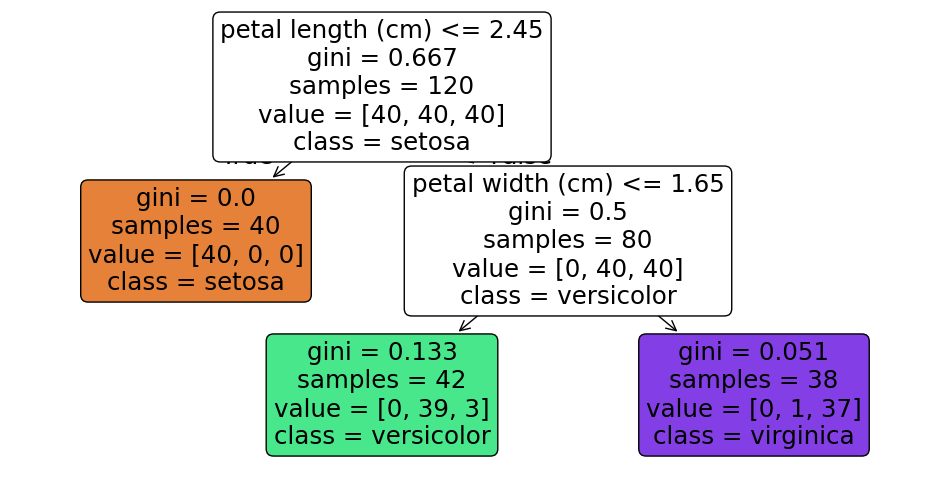

In [69]:
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, class_names=iris.target_names, filled=True, rounded=True,)
plt.show()

## (Advanced) Dataset visualization in 2D

`petal length (cm)` and `petal width (cm)` are enough to see much of the Iris structure.

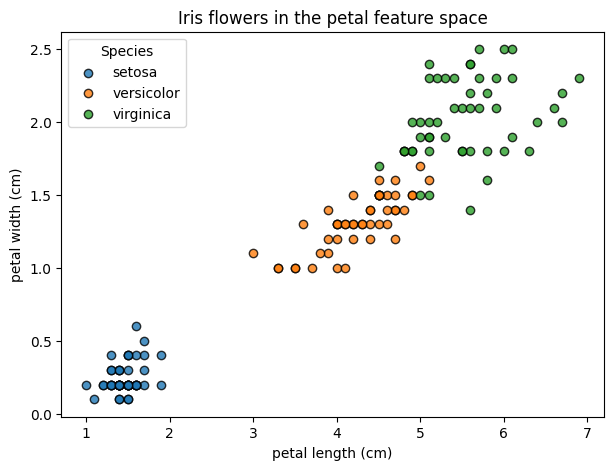

In [70]:
petal_features = ["petal length (cm)", "petal width (cm)"]
species_colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(7, 5))
for target_id, species_name, color in zip(range(len(iris.target_names)), iris.target_names, species_colors):
    species_rows = y == target_id
    plt.scatter(df.loc[species_rows, petal_features[0]], df.loc[species_rows, petal_features[1]], label=species_name, color=color, edgecolor="black", alpha=0.8,)
plt.xlabel(petal_features[0])
plt.ylabel(petal_features[1])
plt.title("Iris flowers in the petal feature space")
plt.legend(title="Species")
plt.show()


## (Advanced) Feature importance

Some models can report which features they used most.

For decision trees, `feature_importances_` is based on impurity decrease

- Every split is scored by how much it makes the child nodes purer than the parent node.
- A feature receives credit for the splits that use it, weighted by how many training samples reach those splits.
- The final scores are normalized so they sum to 1.

In [71]:
importance = pd.Series(model.feature_importances_, index=X.columns, name="importance",).sort_values(ascending=False)
importance.to_frame()


,importance
petal length (cm),0.551867
petal width (cm),0.448133
sepal width (cm),0.000000
sepal length (cm),0.000000


## Try another estimator (i.e., [k-NN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html))

The scikit-learn API is consistent. Switching model often means changing only the estimator class.

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_predictions = knn.predict(X_test)
accuracy_score(y_test, knn_predictions)

1.0

# In-class exercises

## Exercise 1 - pandas column selection

Using the `students` DataFrame:

1. select the `hours_studied` column as a `Series`;
2. select `hours_studied` and `passed` as a `DataFrame`;
3. create `X_students` with only `hours_studied`;
4. create `y_students` with `passed`;
5. print the shapes of `X_students` and `y_students`.

In [73]:
#1
students["hours_studied"]
#2
students[["hours_studied", "passed"]]
#3
X= students[["hours_studied"]]
#4
Y= students["passed"]
#5
print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (4, 1)
Y shape: (4,)


## Exercise 2 - scikit-learn train/test split

Using the Iris DataFrame `df`:

1. create `X_ex` by dropping `target`;
2. create `y_ex` from the `target` column;
3. split the data into train and test sets with `test_size=0.30`, `random_state=42`, and `stratify=y_ex`;
4. print the shapes of the four resulting objects.

In [141]:
# TODO: solve Exercise 4 here
#1
x_ex=df[[	"sepal length (cm)",	"sepal width (cm)",	"petal length (cm)",	"petal width (cm)"]]
#2
y_ex=df[["target"]]
#3
seed=42
X_train, X_test, y_train, y_test = train_test_split(
    x_ex,
    y_ex,
    test_size=0.3,
    random_state=seed,
    stratify=y_ex,
)
#4
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105, 4)
(45, 4)
(105, 1)
(45, 1)


## Exercise 3 - train and evaluate a model

Train a `DecisionTreeClassifier` with `max_depth=3` on the exercise training set.

Then:

1. predict the labels of the test set;
2. compute the accuracy;
3. display a confusion matrix.

In [152]:
model = DecisionTreeClassifier(max_depth=3, random_state=seed)
model.fit(X_train, y_train)
#1
predictions = model.predict(X_test)
#2
accuracy_score(y_test, predictions)
#3
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

0.9777777777777777

## Exercise 4 - compare two models

Train a `KNeighborsClassifier` with `n_neighbors=3` on the same exercise training set.

Compare its accuracy with the decision tree from Exercise 3. Which model performs better on this split?

In [151]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)
accuracy_score(y_test, knn_predictions)
#l'accuracy è più bassa ora


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9555555555555556

# Homework: more pandas practice

The live lab stopped at column selection. The following cells are useful pandas basics, but they are better practiced slowly at home.

Work through them after the lab and run each cell before attempting the homework exercises.

## Missing values and aggregation

Two useful checks before modeling:

- missing values: `.isna().sum()`;
- grouped summaries: `.groupby(...).mean()`.

In [77]:
students.isna().sum()


,0
name,0
hours_studied,0
passed,0


In [78]:
students.groupby("passed")["hours_studied"].mean().to_frame("mean_hours")


,mean_hours
passed,
0,1.5
1,4.5


## Create a slightly richer table

The next table is still small enough to inspect by eye, but it contains the ingredients we need for realistic data work:

- numeric columns;
- a categorical column;
- a missing value;
- a target column.

In [79]:
classroom = pd.DataFrame({
    "student": ["Ada", "Grace", "Katherine", "Alan", "Barbara", "Edsger"],
    "hours_studied": [2, 5, 4, 1, 3, None],
    "attendance": [0.70, 0.95, 0.90, 0.55, 0.80, 0.60],
    "previous_score": [24, 28, 27, 18, 22, 20],
    "track": ["theory", "lab", "lab", "theory", "lab", "theory"],
    "passed": [0, 1, 1, 0, 1, 0],
})

classroom

,student,hours_studied,attendance,previous_score,track,passed
0,Ada,2.0,0.70,24,theory,0
1,Grace,5.0,0.95,28,lab,1
2,Katherine,4.0,0.90,27,lab,1
3,Alan,1.0,0.55,18,theory,0
4,Barbara,3.0,0.80,22,lab,1
5,Edsger,NaN,0.60,20,theory,0


## Column types matter

pandas stores each column with a data type.

Common types:

- `int64` for whole numbers;
- `float64` for decimal numbers and numeric columns with missing values;
- `object` for strings;
- `category` for repeated labels.

Many modeling errors begin with a column having an unexpected type.

In [80]:
classroom.dtypes

,0
student,object
hours_studied,float64
attendance,float64
previous_score,int64
track,object
passed,int64


## Select rows by label or position

Two selection tools appear often:

- `.loc[...]` selects by row/column labels and conditions;
- `.iloc[...]` selects by integer position.

When you are filtering by a condition, `.loc` usually makes the code easier to read.

In [81]:
students[students["passed"] == 1]


,name,hours_studied,passed
1,Grace,5,1
2,Katherine,4,1


In [82]:
# Students who attended at least 80% of classes: keep only selected columns.
classroom.loc[classroom["attendance"] >= 0.80, ["student", "attendance", "passed"]]

,student,attendance,passed
1,Grace,0.95,1
2,Katherine,0.90,1
4,Barbara,0.80,1


In [83]:
# First three rows and first two columns by position.
classroom.iloc[:3, :2]

,student,hours_studied
0,Ada,2.0
1,Grace,5.0
2,Katherine,4.0


## Create new columns

A new column can be calculated from existing columns. This is common in data preparation and feature engineering.

In [84]:
classroom_with_score = classroom.copy()
classroom_with_score["study_attendance_score"] = (
    classroom_with_score["hours_studied"] * classroom_with_score["attendance"]
)

classroom_with_score[["student", "hours_studied", "attendance", "study_attendance_score"]]

,student,hours_studied,attendance,study_attendance_score
0,Ada,2.0,0.70,1.40
1,Grace,5.0,0.95,4.75
2,Katherine,4.0,0.90,3.60
3,Alan,1.0,0.55,0.55
4,Barbara,3.0,0.80,2.40
5,Edsger,NaN,0.60,NaN


## Handle missing values

Missing values are common. A simple first strategy is to replace a missing numeric value with the column mean.

This is not always the best statistical choice, but it is a clear starting point for this first lab.

In [85]:
classroom_clean = classroom.copy()
mean_hours = classroom_clean["hours_studied"].mean()
classroom_clean["hours_studied"] = classroom_clean["hours_studied"].fillna(mean_hours)

classroom_clean

,student,hours_studied,attendance,previous_score,track,passed
0,Ada,2.0,0.70,24,theory,0
1,Grace,5.0,0.95,28,lab,1
2,Katherine,4.0,0.90,27,lab,1
3,Alan,1.0,0.55,18,theory,0
4,Barbara,3.0,0.80,22,lab,1
5,Edsger,3.0,0.60,20,theory,0


## Sort rows

Sorting helps you inspect extremes and check whether values make sense.

In [86]:
classroom_clean.sort_values("previous_score", ascending=False)

,student,hours_studied,attendance,previous_score,track,passed
1,Grace,5.0,0.95,28,lab,1
2,Katherine,4.0,0.90,27,lab,1
0,Ada,2.0,0.70,24,theory,0
4,Barbara,3.0,0.80,22,lab,1
5,Edsger,3.0,0.60,20,theory,0
3,Alan,1.0,0.55,18,theory,0


## Group by a category

Grouping answers questions such as: do lab-track and theory-track students look different in this small example?

In [87]:
classroom_clean.groupby("track")[["hours_studied", "attendance", "previous_score", "passed"]].mean().round(2)

,hours_studied,attendance,previous_score,passed
track,,,,
lab,4.0,0.88,25.67,1.0
theory,2.0,0.62,20.67,0.0


## Preprocessing: convert categories to numbers

Many estimators need numeric input. If a DataFrame contains text labels, convert them before modeling.

`pd.get_dummies(...)` is a beginner-friendly way to one-hot encode categorical columns.

In [88]:
classroom_features = classroom_clean.drop(columns=["student", "passed"])
classroom_target = classroom_clean["passed"]

classroom_features_encoded = pd.get_dummies(classroom_features, columns=["track"])
classroom_features_encoded

,hours_studied,attendance,previous_score,track_lab,track_theory
0,2.0,0.70,24,False,True
1,5.0,0.95,28,True,False
2,4.0,0.90,27,True,False
3,1.0,0.55,18,False,True
4,3.0,0.80,22,True,False
5,3.0,0.60,20,False,True


## Homework exercises

These exercises use the extra pandas operations introduced in the homework section.

## Homework Exercise 1 - pandas inspection

Using `classroom_clean`, write code that:

1. shows the first 3 rows;
2. prints the number of rows and columns;
3. computes the average `attendance`;
4. counts how many students passed and failed.

In [89]:
# TODO: solve Exercise 1 here


## Homework Exercise 2 - pandas filtering and sorting

Using `classroom_clean`, create a table with students who have:

- `attendance >= 0.75`; and
- `previous_score >= 22`.

Show only `student`, `attendance`, `previous_score`, and `passed`, sorted by `previous_score` from highest to lowest.

In [90]:
# TODO: solve Exercise 2 here


## Homework Exercise 3 - pandas feature creation

Create a new DataFrame named `classroom_exercise` and add a column named `ready_score`:

```python
ready_score = hours_studied + 10 * attendance + previous_score / 10
```

Then display `student`, `ready_score`, and `passed`.

In [91]:
# TODO: solve Exercise 3 here


# Final reflection

Answer in a markdown cell:

1. What is the difference between a pandas `DataFrame` and a pandas `Series`?
2. Why do we split data into training and test sets?
3. What does `.fit(...)` do?
4. What does `.predict(...)` do?
5. Why should the target column not be included in `X`?